In [1]:
# ambiente anaconda
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/Udemy/bin/python


In [2]:
# versão do python
print(sys.version)

3.11.9 (main, Apr 19 2024, 16:48:06) [GCC 11.2.0]


In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

import os
# DRIVE_DIRECTORY = "curso_ml"
# DRIVE_DIRECTORY = os.path.join("/content/drive/MyDrive", DRIVE_DIRECTORY)

# Aprendizagem baseada em instâncias - KNN

In [4]:
import pickle

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from yellowbrick.classifier import ConfusionMatrix

Comece recuperando os dados preditores, de treino e de teste, a partir do arquivo `cover_type.pkl` salvo na pasta do Drive. Lembre-se de que você deve instanciar as variáveis `X` e `y`, dos splits `train` e `test`,  na mesma ordem que salvou.

In [7]:
DRIVE_DIRECTORY_fonte ='../../2-3-Classificacao/Exercicio_Faltante_Classificacao'
with open(os.path.join(DRIVE_DIRECTORY_fonte, "cover_type_exer3.pkl"), "rb") as f:
    (X_train, y_train, X_test, y_test) = pickle.load(f)

Instancie e ajuste um classificador do tipo `KNeighborsClassifier`. Não precisa passar nenhum parâmetro, pois você pode utilizar os valores padrão: `n_neighbors=5`, `p=2` e `metric='minkowski'`.

In [8]:
knn_classifier = KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [9]:
knn_classifier.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [10]:
# KNN: Classifica por 'vizinhança'. Diz-me com quem andas e te direi quem és.
# n_neighbors=5: O voto é decidido pelos 5 vizinhos mais próximos.
# p=2: Usa a distância em linha reta (Euclidiana) para achar os vizinhos.

KNeighborsClassifier(): Cria o modelo. Por padrão, ele vai olhar para os 5 vizinhos mais próximos (n_neighbors: 5).

knn_classifier.fit(X_train, y_train): Diferente de outros modelos, o KNN não "aprende" nada no treino. Ele apenas memoriza a posição de todos os pontos no espaço. O trabalho pesado do KNN acontece na hora de prever.

### Entendendo os Parâmetros (O dicionário)

- n_neighbors: 5: É o valor de $K$. O modelo olha para os 5 pontos mais perto para decidir o voto.

- metric: 'minkowski' e p: 2: Isso define como a "distância" é calculada. Com p=2, ele usa a Distância Euclidiana (a linha reta entre dois pontos, como usamos em geometria).

- weights: 'uniform': Todos os 5 vizinhos têm o mesmo peso no voto, independentemente de estarem um pouco mais perto ou mais longe.

- algorithm: 'auto': O Python decide sozinho a forma mais rápida de procurar os vizinhos (usando estruturas de dados como KD-Tree ou Ball Tree).

Faça e exiba a predição no split de teste.

In [11]:
y_pred = knn_classifier.predict(X_test)
y_pred

array([4, 4, 5, ..., 6, 6, 2], shape=(2500,))

Calcule a acurácia.

In [12]:
accuracy_score(y_test, y_pred)

0.7552

In [13]:
print(f'tivemos {accuracy_score(y_test, y_pred)*100:.2f} % de acurácia ou acerto')

tivemos 75.52 % de acurácia ou acerto


Exiba a matriz de confusão.

0.7552

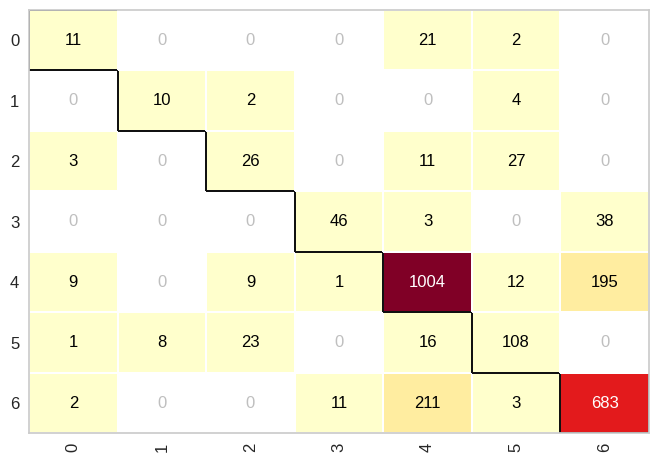

In [14]:
cm = ConfusionMatrix(knn_classifier)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### Eixo Vertical (True Class): É a realidade. O que a árvore realmente é no mundo real.

#### Eixo Horizontal (Predicted Class): É o palpite do modelo. O que o knn achou que era.

Exiba o reporte de classificação.

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.42      0.32      0.37        34
           1       0.56      0.62      0.59        16
           2       0.43      0.39      0.41        67
           3       0.79      0.53      0.63        87
           4       0.79      0.82      0.80      1230
           5       0.69      0.69      0.69       156
           6       0.75      0.75      0.75       910

    accuracy                           0.76      2500
   macro avg       0.63      0.59      0.61      2500
weighted avg       0.75      0.76      0.75      2500



In [16]:
# melhores resultados: classes 3, 4, 5 e 6
#ruim para o 0

1. Precision (Precisão)
Pergunta: "De todas as vezes que o modelo disse que era Aspen, quantas eram realmente Aspen?"

Foco: Evitar alarmes falsos.

Se a precisão é 0.80, significa que quando o modelo aponta para uma árvore e diz "É Aspen", ele acerta 80% das vezes.

2. Recall (Revocação / Sensibilidade)
Pergunta: "De todas as árvores Aspen que existem de verdade no mato, quantas o modelo conseguiu encontrar?"

Foco: Não deixar passar nada.

Se o recall é 0.60, significa que o modelo só achou 60% das Aspens totais; as outras 40% ele confundiu com outro tipo.

3. F1-Score
O que é: Uma média (harmônica) entre a Precisão e o Recall.

Foco: Equilíbrio.

É a melhor métrica para olhar se você quer um resumo rápido, pois se a Precisão for ótima mas o Recall for péssimo (ou vice-versa), o F1-Score cai.

4. Support (Suporte)
O que é: A quantidade real de exemplos daquela classe no seu conjunto de testes.

Foco: Contexto.

Se o suporte de uma árvore é 10 e de outra é 5000, você sabe que o resultado da primeira não é tão confiável estatisticamente quanto o da segunda.

In [17]:
from sklearn.preprocessing import LabelEncoder

# # 1. Recriamos o objeto
# label_encoder = LabelEncoder()

# # 2. "Ensinamos" a ele os nomes novamente usando a coluna original do DataFrame
# # Isso restaura a memória do encoder (o mapeamento de nomes para números)
# label_encoder.fit(base['Cover_Type'])

# # 3. Agora o comando vai funcionar!
# y_pred_strings = label_encoder.inverse_transform(y_pred)
# y_test_strings = label_encoder.inverse_transform(y_test)

# print("Nomes traduzidos com sucesso!")
# print(label_encoder.classes_)

#---------------------------------------

# # 1. Primeiro, geramos as previsões (que virão como números: 0, 1, 2...)
# y_pred = naive_classifier.predict(X_test)

# # 2. Agora, traduzimos os números de volta para os nomes das árvores
# y_pred_strings = label_encoder.inverse_transform(y_pred)

# # 3. Fazemos o mesmo para o y_test para podermos comparar "Nome vs Nome"
# y_test_strings = label_encoder.inverse_transform(y_test)

# # 4. Criamos uma tabela para você ver os 10 primeiros resultados reais
# import pandas as pd
# df_resultados = pd.DataFrame({
#     'Classe Real': y_test_strings,
#     'Previsão do Modelo': y_pred_strings
# })

# print("--- Primeiros 10 resultados traduzidos ---")
# print(df_resultados.head(10))
#----------------------------------

# # 1. Converte o array de números (y_pred) para os nomes originais (strings)
# y_pred_nomes = label_encoder.inverse_transform(y_pred)

# # 2. Se quiser ver os nomes reais do conjunto de teste para comparar
# y_test_nomes = label_encoder.inverse_transform(y_test)

# # 3. Vamos ver os 10 primeiros resultados lado a lado
# import pandas as pd
# comparacao = pd.DataFrame({
#     'Real': y_test_nomes,
#     'Previsão': y_pred_nomes
# })

# print(comparacao.head(10))

# no arquivo original => M3_Exercicio_classificacao_pre_processamento_dos_dados.ipynb


In [18]:
# no arquivo original => M3_Exercicio_classificacao_pre_processamento_dos_dados.ipynb
# y = base.iloc[:, -1].values
# base.columns[-1] # a coluna de interesse, o target, ou seja a classe é esta
# 'Cover_Type'

# label_encoder = LabelEncoder()
# y = label_encoder.fit_transform(y)
# # Mostra a lista de nomes na ordem (0, 1, 2...)
# print(label_encoder.classes_)
# {0: 'Aspen', 1: 'Cottonwood/Willow', 2: 'Douglas-fir', 3: 'Krummholz', 4: 'Lodgepole Pine', 5: 'Ponderosa Pine', 6: 'Spruce/Fir'}



In [19]:
import pandas as pd

# O seu dicionário de mapeamento
mapa_nomes = {0: 'Aspen', 1: 'Cottonwood/Willow', 2: 'Douglas-fir', 
              3: 'Krummholz', 4: 'Lodgepole Pine', 5: 'Ponderosa Pine', 
              6: 'Spruce/Fir'}

# Criando o DataFrame de comparação
df_comparacao = pd.DataFrame({
    'Real': y_test,
    'Previsão': y_pred
})

# Traduzindo as colunas usando o dicionário
df_comparacao['Real_Nome'] = df_comparacao['Real'].map(mapa_nomes)
df_comparacao['Previsao_Nome'] = df_comparacao['Previsão'].map(mapa_nomes)

display(df_comparacao[['Real_Nome', 'Previsao_Nome']].head(10))

,Real_Nome,Previsao_Nome
0,Lodgepole Pine,Lodgepole Pine
1,Lodgepole Pine,Lodgepole Pine
2,Cottonwood/Willow,Ponderosa Pine
3,Lodgepole Pine,Lodgepole Pine
4,Lodgepole Pine,Lodgepole Pine
5,Spruce/Fir,Spruce/Fir
6,Lodgepole Pine,Lodgepole Pine
7,Spruce/Fir,Spruce/Fir
8,Lodgepole Pine,Spruce/Fir
9,Lodgepole Pine,Spruce/Fir
